This notebook will take the results of different runs of COMPAS and plot those difference

In [1]:
#imports!

# let's import things
import h5py as h5 
import pandas as pd
from astropy.table import Table
from astropy import units as u
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text.latex', preamble=r'\usepackage{textgreek}')
plt.rc('font', family='serif')
import sys
import os
from scipy import stats
import seaborn as sns
import matplotlib as mpl

# Add the subdir to sys.path for our created scripts
# sys.path.append('/home/jovyan/home/research_work/useful_py_scripts/')
# sys.path.append('/home/jovyan/home/research_work/making_figures/paper_figures/')
sys.path.append('/home/msantiago/research_work/useful_py_scripts/')
sys.path.append('/home/msantiago/research_work/making_figures/paper_figures/')


# Now you can import the module
import useful_fncs
import figure_utils
import utils_from_others

# import for axes labels 
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif"
})

### 1) Get the results of the merger rate at z = 0 for $\alpha_{CE}$ of 0.25, 0.5, 0.75, 1, 2

In [2]:
# let's make a function where we can get these results quickly 

def merger_rate_z0_result(pathToH5):

    # we first need to gather the information for the file of interest
    # reading in the HDF5 file

    Data  = h5.File(pathToH5, "r")

# To make the variations plot we need the stellar types, masses, and rate at z=0

    DCOs = Data['BSE_Double_Compact_Objects'] # gathering the DCO group
    DCO_mask = Data['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['DCOmask'][()]

# HDF5 files are most efficent if you apply the mask after reading in the key of interest

    stellar_types_1_all = DCOs['Stellar_Type(1)'][()]
    stellar_types_1 = stellar_types_1_all[DCO_mask]

    stellar_types_2_all = DCOs['Stellar_Type(2)'][()]
    stellar_types_2 = stellar_types_2_all[DCO_mask]

    mass1_all = DCOs['Mass(1)'][()]
    mass1 = mass1_all[DCO_mask]

    mass2_all = DCOs['Mass(2)'][()]
    mass2 = mass2_all[DCO_mask]

    rates_z0_DCO = Data['Rates_mu00.025_muz-0.049_alpha-1.79_sigma01.129_sigmaz0.048']['merger_rate_z0'][()]

    Data.close()

    # let's make sure that at least one of these white dwarfs are COWD
    HeWD_bool,COWD_bool,ONeWD_bool,HeCOWD_bool,HeONeWD_bool,COHeWD_bool,COONeWD_bool,ONeHeWD_bool,ONeCOWD_bool = useful_fncs.WD_BINARY_BOOLS(stellar_types_1, stellar_types_2)
    carbon_oxygen_bool = np.logical_or(ONeCOWD_bool,np.logical_or(COONeWD_bool,np.logical_or(COHeWD_bool,np.logical_or(COWD_bool,HeCOWD_bool))))


    # let's now sort our data into the mass regimes we care about
    # let's add the flags for specific calssifications of SN Ia

    SN_Ia_HVS,two_star_SNIA,Champagne_Supernova = useful_fncs.check_if_SNIA(mass1[carbon_oxygen_bool],mass2[carbon_oxygen_bool])

    # let's now gather the merger rate at redshift zero
    WDWD_merger_rate_Z0 = rates_z0_DCO[carbon_oxygen_bool]
    cowd_rate = np.sum(WDWD_merger_rate_Z0)

    # # let's now get the values of these merger rates for all of the systems that fall within specific regimes
    # SN_Ia_HVS_z0_rate = np.sum(WDWD_merger_rate_Z0[SN_Ia_HVS==True])
    two_star_SNIA_z0_rate = np.sum(WDWD_merger_rate_Z0[two_star_SNIA==True])
    # Champagne_Supernova_z0_rate = np.sum(WDWD_merger_rate_Z0[Champagne_Supernova== True])
    # any_SNIA = np.logical_or(Champagne_Supernova== True,
    #                      SN_Ia_HVS==True,two_star_SNIA==True)
    # tot_SNe_Ia = np.sum(WDWD_merger_rate_Z0[any_SNIA])


    #let's get the merger rates for Mtot>mchan
    mtot_chan_more = mass1 + mass2 > 1.4
    mtot_chan_bool = carbon_oxygen_bool*mtot_chan_more
    mchan_rate = np.sum(rates_z0_DCO[mtot_chan_bool])

    # the NSNS merger rate
    # let's gather the NSNS merger information
    NSNS_bool = np.logical_and(stellar_types_1==13,stellar_types_2==13)
    nsns_rate = np.sum(rates_z0_DCO[NSNS_bool],axis=0)


    # return([SN_Ia_HVS_z0_rate,two_star_SNIA_z0_rate,Champagne_Supernova_z0_rate,tot_SNe_Ia,cowd_rate,mchan_rate,nsns_rate])
    return([cowd_rate,mchan_rate,two_star_SNIA_z0_rate,nsns_rate])


In [12]:
merger_rates_z0_CEalpha025 = merger_rate_z0_result('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha025/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha05 = merger_rate_z0_result('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha05/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha075 = merger_rate_z0_result('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha075/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha1 = merger_rate_z0_result('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N1e6_NSNS_fid/MainRun/COMPAS_Output_wWeights.h5')
merger_rates_z0_CEalpha2 = merger_rate_z0_result('/expanse/lustre/scratch/msantiago/temp_project/COMPAS_DATA/N5e6_NSNS_CE_alpha2/MainRun/COMPAS_Output_wWeights.h5')


### 2) Let's now define the different variations we have

In [29]:
cowdwd_SNe_Ia  = [merger_rates_z0_CEalpha025[0],merger_rates_z0_CEalpha05[0],merger_rates_z0_CEalpha075[0],merger_rates_z0_CEalpha1[0],merger_rates_z0_CEalpha2[0]]
mchan_SNe_Ia  = [merger_rates_z0_CEalpha025[1],merger_rates_z0_CEalpha05[1],merger_rates_z0_CEalpha075[1],merger_rates_z0_CEalpha1[1],merger_rates_z0_CEalpha2[1]]
rates_two_star_SNIA  = [merger_rates_z0_CEalpha025[2],merger_rates_z0_CEalpha05[2],merger_rates_z0_CEalpha075[2],merger_rates_z0_CEalpha1[2],merger_rates_z0_CEalpha2[2]]
nsns_rates  = [merger_rates_z0_CEalpha025[3],merger_rates_z0_CEalpha05[3],merger_rates_z0_CEalpha075[3],merger_rates_z0_CEalpha1[3],merger_rates_z0_CEalpha2[3]]

In [14]:
# variations_compas = [0.25,0.5,0.75,1.0,1.25]
# # we did not actually do alpha_ce = 1.25 but to remove the white space on the plot below we call the position 1.25 but it corresponds to alpha_Ce=2.00
# # rates_SN_Ia_HVS  =[merger_rates_z0_CEalpha025[0],merger_rates_z0_CEalpha05[0],merger_rates_z0_CEalpha075[0],merger_rates_z0_CEalpha1[0],merger_rates_z0_CEalpha2[0]]
# rates_two_star_SNIA  =[merger_rates_z0_CEalpha025[1],merger_rates_z0_CEalpha05[1],merger_rates_z0_CEalpha075[1],merger_rates_z0_CEalpha1[1],merger_rates_z0_CEalpha2[1]]
# # rates_Champagne_Supernova  =[merger_rates_z0_CEalpha025[2],merger_rates_z0_CEalpha05[2],merger_rates_z0_CEalpha075[2],merger_rates_z0_CEalpha1[2],merger_rates_z0_CEalpha2[2]]
# # total_SNe_Ia  =[merger_rates_z0_CEalpha025[3],merger_rates_z0_CEalpha05[3],merger_rates_z0_CEalpha075[3],merger_rates_z0_CEalpha1[3],merger_rates_z0_CEalpha2[3]]
# # cowdwd_SNe_Ia  =[merger_rates_z0_CEalpha025[4],merger_rates_z0_CEalpha05[4],merger_rates_z0_CEalpha075[4],merger_rates_z0_CEalpha1[4],merger_rates_z0_CEalpha2[4]]
# # mchan_SNe_Ia  =[merger_rates_z0_CEalpha025[5],merger_rates_z0_CEalpha05[5],merger_rates_z0_CEalpha075[5],merger_rates_z0_CEalpha1[5],merger_rates_z0_CEalpha2[5]]
# # nsns_rates  =[merger_rates_z0_CEalpha025[6],merger_rates_z0_CEalpha05[6],merger_rates_z0_CEalpha075[6],merger_rates_z0_CEalpha1[6],merger_rates_z0_CEalpha2[6]]

### 3) Let's now make the plot!

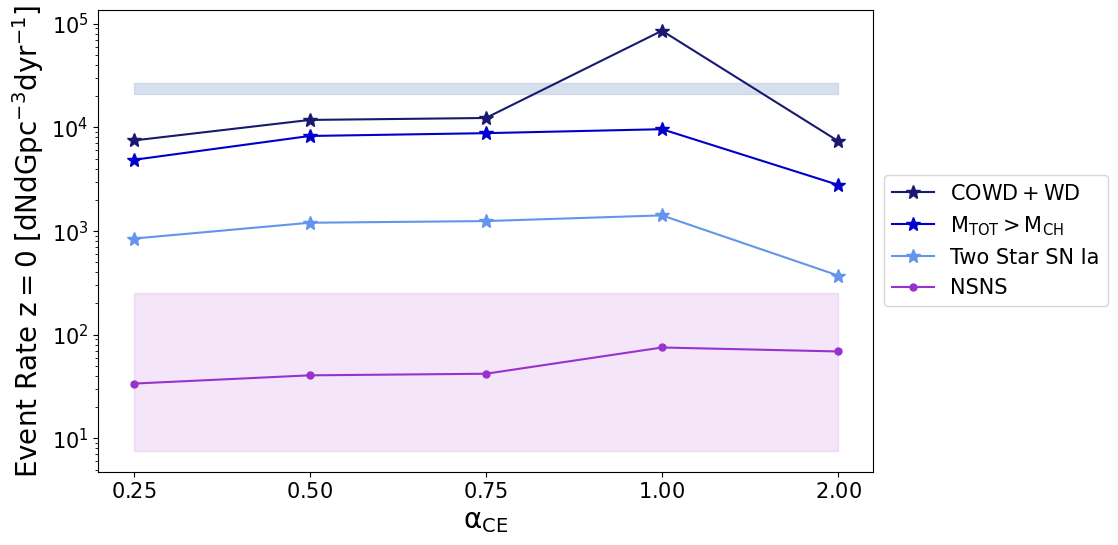

In [40]:
# we want all of the of SN to have the same color marker
markersize = 10
fig, ax = plt.subplots(figsize = (10,6))

x_positions = [0, 1, 2, 3, 4]
plt.plot(x_positions,cowdwd_SNe_Ia,'*', linestyle='-',label=r'$\mathrm{COWD + WD}$', color='midnightblue',markersize = markersize)
plt.plot(x_positions,mchan_SNe_Ia,'*', linestyle='-', label=r'$\mathrm{M_{TOT}>M_{CH}}$', color='mediumblue',markersize = markersize)
plt.plot(x_positions,rates_two_star_SNIA,'*', linestyle='-', label='Two Star SN Ia', color='cornflowerblue',markersize = markersize)
plt.plot(x_positions,nsns_rates,'.', linestyle='-', label='NSNS', color='darkorchid',markersize = markersize)

h_little = 0.6766

## Briel et al 2022 rates at z = 0
plt.fill_between([min(x_positions),max(x_positions)], 
                (0.77-0.10)*(10**5)*(h_little**3),
                (0.77+0.10)*(10**5)*(h_little**3), 
                alpha=0.50, 
                color="lightsteelblue")

### NNS Observed rate
plt.fill_between([min(x_positions),max(x_positions)], 
                7.6,
                250, 
                alpha=0.15, 
                color="mediumorchid")

# axes labels 
plt.yscale('log')
plt.ylabel(r"Event Rate $\mathrm{z=0}$ [$\mathrm{dNdGpc^{-3}dyr^{-1}}$]",fontsize=20)
plt.xlabel(r"$\mathrm{\alpha_{CE}}$", fontsize = 20)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=15)
plt.xticks(x_positions, [r"$\mathrm{0.25}$", r"$\mathrm{0.50}$", r"$\mathrm{0.75}$", r"$\mathrm{1.00}$", r"$\mathrm{2.00}$"], fontsize=15);
plt.yticks(fontsize=15);

# plt.savefig("./variations_plots/CEalpha_variations_NSNSoptimization.png",bbox_inches='tight',pad_inches=0.2)

In [10]:
0.77*(10**5)*(h_little**3)

23849.907858391998

In [11]:
nsns_rates[3]

np.float64(56.36442294397306)